<a href="https://colab.research.google.com/github/Nivethika-hub/nivethika-codebooster-2026/blob/main/Day-2/mini_project_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot
import warnings
warnings.filterwarnings('ignore')

print("All libraries impoted successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries impoted successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [3]:
df=pd.read_csv("student_performance.csv")
print(f"Dataset loaded:{df.shape[0]} students ,{df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}")

Dataset loaded:30 students ,13 columns
Columns : ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [4]:
conn=sqlite3.connect('college.db')

In [5]:
cursor=conn.cursor()
df.to_sql(
    'students' ,
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print("database college.db has been created successfully")
print(f"Table students has {count} rows")

database college.db has been created successfully
Table students has 30 rows


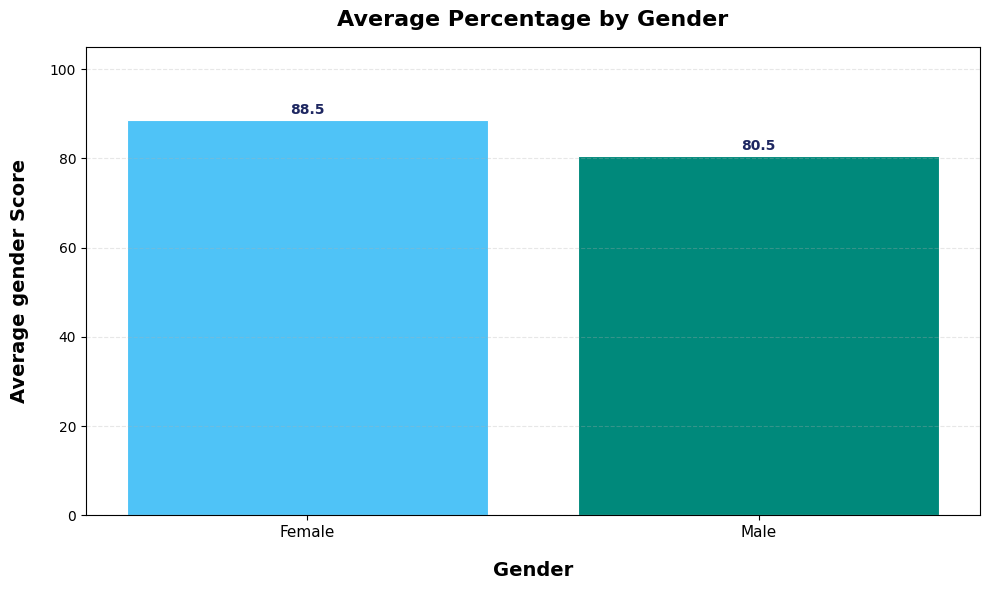

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

chart1_sql="""
SELECT gender,ROUND(AVG(attendance_percentage),2) AS avg_percentage
FROM students
GROUP BY gender
ORDER BY avg_percentage DESC
"""
chart1_df=pd.read_sql_query(chart1_sql,conn)

fig,ax=plt.subplots(figsize=(10,6))

bar_colors=['#4FC3F7','#00897B','#E67E32','#8E44AD'] # Corrected hex color code

bars=ax.bar(
    chart1_df['gender'], # Corrected variable name
    chart1_df['avg_percentage'],   # Corrected variable name
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
   height=bar.get_height()
   ax.text(
       bar.get_x()+bar.get_width()/2,
       height+0.8,
       f'{height:.1f}', # Changed to .1f for one decimal place
       ha='center',
       va='bottom',
       fontsize=10,
       fontweight='bold',
       color='#1E2761'
   )

# Moved these plotting commands outside the loop
ax.set_title('Average Percentage by Gender',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Gender',fontsize=14,fontweight='bold',labelpad=15)
ax.set_ylabel('Average gender Score',fontsize=14,fontweight='bold',labelpad=15)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()